In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# posterior_4D_Mac = np.load("./posterior/posterior_4D.npy")
#posterior_4D = np.load("./posterior/posterior_4D_HOf_40.npy")
posterior_4D = np.load("./posterior/posterior_4D_MacF.npy")

In [10]:
""" F_array=np.linspace(0.01, 1.6, 20)
sigma_host_array=np.linspace(0.01,1.5,20)
e_mu_array=np.linspace(0.01, 200, 20)
HOf_array=np.linspace(1.0, 5.0, 20) """

# F_array=np.linspace(0.01, 1.0, 20)
# sigma_host_array=np.linspace(0.2,1.4,20)
# e_mu_array=np.linspace(50,250, 20)
# HOf_array=np.linspace(1.0, 5.0, 40)

F_array=np.linspace(1, 5, 40)
sigma_host_array=np.linspace(0.2,1.4,10)
e_mu_array=np.linspace(50, 250, 20)
HOf_array=np.linspace(1.0, 5.0, 20)

F_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    F_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, HOf_array_4D: {HOf_array_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (40, 20, 10, 20), HOf_array_4D: (40, 20, 10, 20), sigma_host_4D: (40, 20, 10, 20), e_mu_4D: (40, 20, 10, 20)
Shape of F_h: (20, 40), h_F: (20, 40), F_sigma: (10, 40), sigma_F: (10, 40), F_e_mu: (20, 40), e_mu_F: (20, 40)


In [11]:
Grid2D = {
    "F_h": F_h,
    "h_F": h_F,
    "F_sigma":F_sigma,
    "sigma_F":sigma_F,
    "F_e_mu":F_e_mu,
    "e_mu_F":e_mu_F,
    "h_sigma":h_sigma,
    "sigma_h":sigma_h,
    "h_e_mu":h_e_mu,
    "e_mu_h":e_mu_h,
    "sigma_e_mu":sigma_e_mu,
    "e_mu_sigma":e_mu_sigma
}

In [5]:
H_cmb=67.4

H_cmb1=67.4-0.5
H_cmb2=67.4+0.5
s_Hcmb=0.5

O_b=0.0224/(H_cmb/100)**2
s_Ob=O_b*np.sqrt(0.0001**2/0.0224**2+2*s_Hcmb**2/H_cmb**2)
print(O_b)

O_b1=(0.0224-0.0001)/(H_cmb2/100)**2
O_b2=(0.0224+0.0001)/(H_cmb1/100)**2

coscmb=H_cmb*O_b
coscmb1=H_cmb1*O_b1
coscmb2=H_cmb2*O_b2

print([coscmb1*0.82,coscmb*0.86,coscmb2*0.9])
print(OMEGA_BARYONS)

0.049309230511847414
[2.6534156398237894, 2.8581602373887236, 3.072151058738362]
0.04897


In [6]:
H_SN=73.30
H_SN1=73.30+1.04
H_SN2=73.30-1.04
s_HSN=1.04

cosSN=H_SN*O_b
cosSN1=H_SN1*O_b
cosSN2=H_SN2*O_b

In [7]:
print(HUBBLE*OMEGA_BARYONS*0.9)

2.9819791799999997


In [8]:
print(HUBBLE*OMEGA_BARYONS*0.84)

2.7831805679999997


[5.0251850253821555, 68.26253497114881, 9.959552952303412]
[0.06444431704612975, 0.8710056390977444, 0.12724451150733354]
[0.060043584938711383, 0.8008974089384444, 0.11740272814506712]


/tmp/ipykernel_11202/595803965.py:84: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


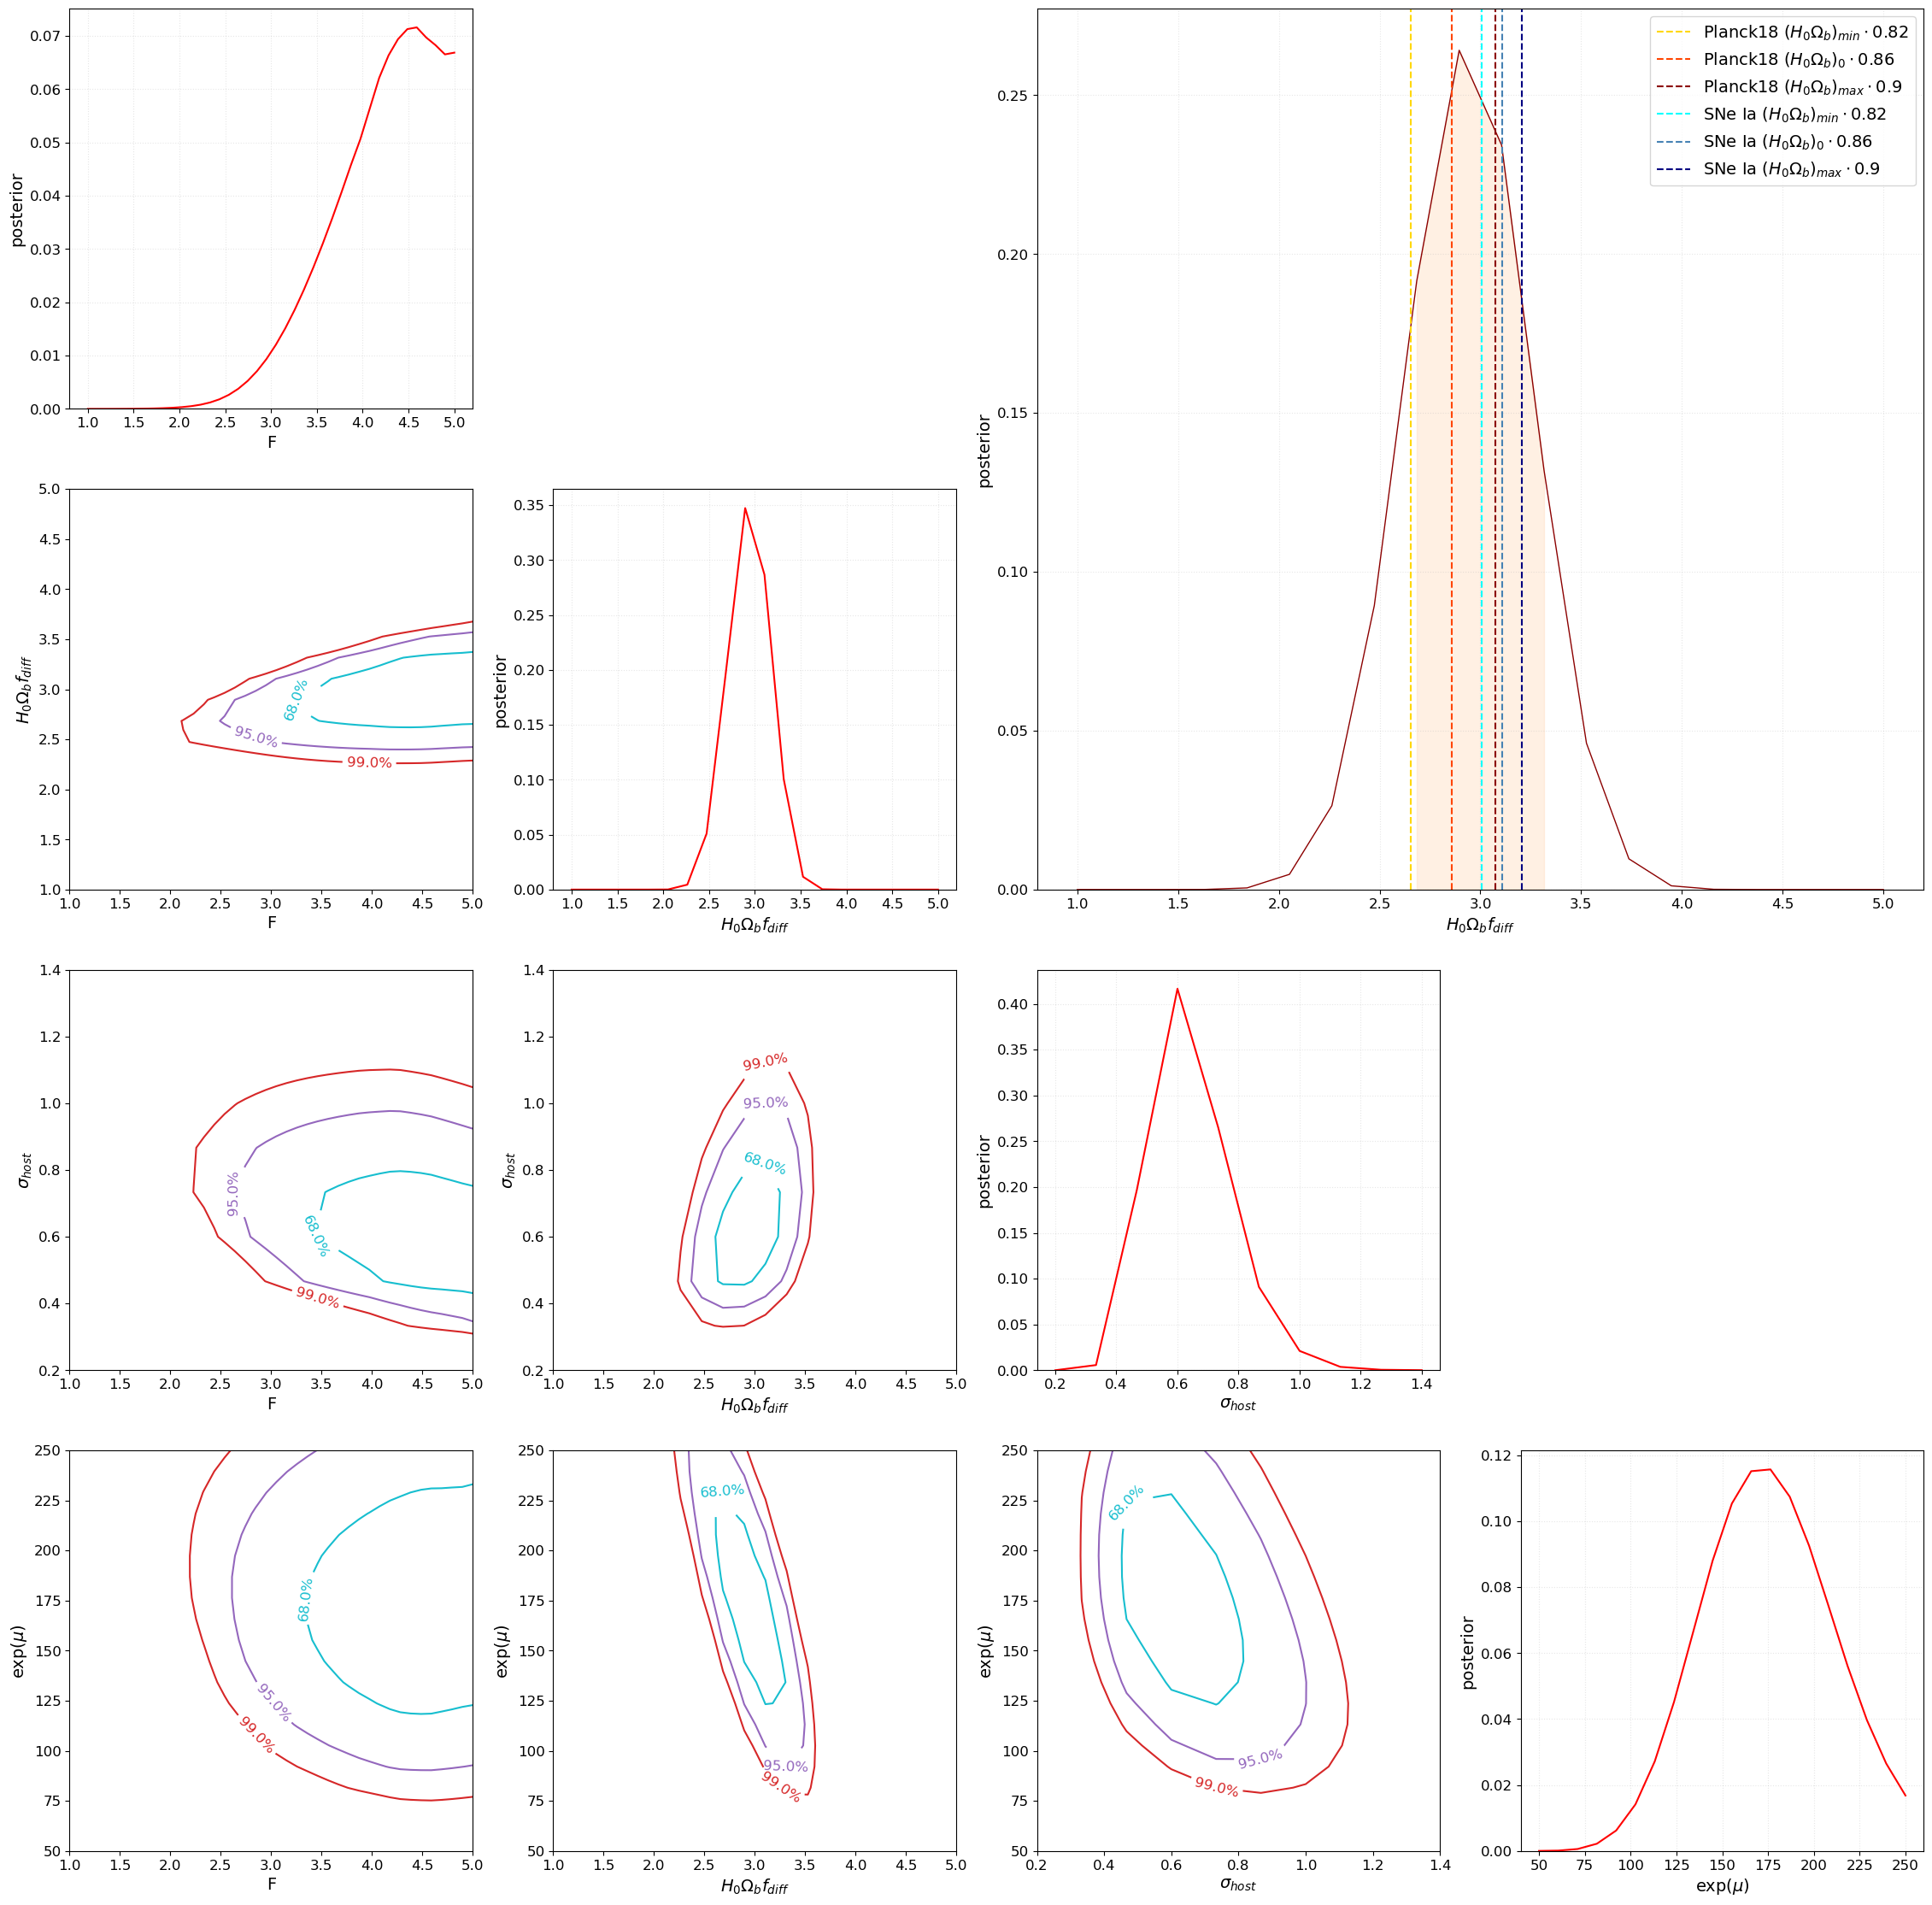

In [12]:
from scipy.stats import chi2
from scipy.ndimage import gaussian_filter1d

stats_df = pd.DataFrame(columns=['Var','Mean', 'Median', 'Mode', 'Lower68','Upper68', 'Lower95','Upper95'])

# confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "F", F_array),
    ("$H_0 \Omega_b f_{diff}$", "h" ,HOf_array),
    ("$\sigma_{host}$", "sigma", sigma_host_array),
    ("$\exp(\mu)$", "e_mu", e_mu_array),
]

vars_name=['F','$H_0 \Omega_b f_{diff}$','$\sigma_{host}$','$\exp(\mu)$']

fig, axes = plt.subplots(4, 4, figsize=(28,28))
axes = axes.flatten()

fsize=14

# plt.figure(figsize=(25, 25))
for idx, (x_name, x, x_array) in enumerate(grid_pairs):
    for idy, (y_name, y, y_array) in enumerate(grid_pairs):
        marginal_axes = [k for k in range(len(grid_pairs)) if k != idx and k != idy]
        marginal_axes=tuple(marginal_axes)
        #marginal_axes="(" + ",".join(map(str, marginal_axes)) + ")"
         
        ax = axes[len(vars_name)*idy+idx]
        
        # plt.subplot(len(vars_name), len(vars_name), len(vars_name)*idy+idx+1)
        
        marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
        marginal_prob = marginal_prob/np.sum(marginal_prob)
    
        if (x==y):
            # marginal_prob = gaussian_filter1d(marginal_prob, sigma=1)
            # marginal_prob = marginal_prob/np.sum(marginal_prob)
            
            # mean
            mean_value = np.sum(x_array * marginal_prob)
            
            # median
            cdf = np.cumsum(marginal_prob)
            median_idx = np.searchsorted(cdf, 0.5)
            median_value = x_array[median_idx]
            
            # mode众数
            mode_idx = np.argmax(marginal_prob)
            mode_value = x_array[mode_idx]
            
            #variance
            variance = np.sum((x_array - mean_value)**2 * marginal_prob)
            std_dev = np.sqrt(variance)
            
            #68% ±1σ
            lower_percentile1 = 0.16  # 16%
            upper_percentile1 = 0.84  # 84%
            lower_idx1 = np.searchsorted(cdf, lower_percentile1)
            upper_idx1 = np.searchsorted(cdf, upper_percentile1)
            lower_bound1 = x_array[lower_idx1]
            upper_bound1 = x_array[upper_idx1]
            
            
            lower_percentile2 = 0.025  # 16%
            upper_percentile2 = 0.975  # 84%
            lower_idx2 = np.searchsorted(cdf, lower_percentile2)
            upper_idx2 = np.searchsorted(cdf, upper_percentile2)
            lower_bound2 = x_array[lower_idx2]
            upper_bound2 = x_array[upper_idx2]
            
            stats_df.loc[len(stats_df)]=[x,mean_value,median_value,mode_value,lower_bound1,upper_bound1,lower_bound2,upper_bound2]
            
            ax.grid(alpha=0.3, linestyle=':')
            ax.tick_params(axis='both', labelsize=fsize-2)
            ax.plot(x_array,marginal_prob,color='red')
            ax.set_xlabel(x_name, fontsize=fsize)
            ax.set_ylabel('posterior', fontsize=fsize)
            ax.set_ylim(bottom=0)
            
        elif (idx<idy):
            delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
            
            X=f"{x}_{y}"
            Y=f"{y}_{x}"
            cs = ax.contour(Grid2D[X], Grid2D[Y], delta_chi2.T, levels=contour_levels, 
                    # colors=['r', 'b', 'g']
                    colors=['#17becf','#9467bd','#d62728']
                    # colors=['#8B0000', '#FF4500', '#FFD700']
                    )

            ax.tick_params(axis='both', labelsize=fsize-2)
            ax.set_xlabel(x_name, fontsize=fsize)
            ax.set_ylabel(y_name, fontsize=fsize)
            # ax.set_title(f"{x_name} vs {y_name}")
    
            fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
                contour_levels[1]: f'{confidence_levels[1]*100}%',
                contour_levels[2]: f'{confidence_levels[2]*100}%',
                }
            ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=fsize-2)
        else:
            ax.set_visible(False)

P_h = np.sum(posterior_4D, axis=(0,2,3))
# P_h_Mac = np.sum(posterior_4D_Mac, axis=(0,2,3))

P_h=P_h/np.sum(P_h)
# P_h_Mac=P_h_Mac/np.sum(P_h_Mac)

P_h=gaussian_filter1d(P_h, sigma=1)
# P_h_Mac=gaussian_filter1d(P_h_Mac, sigma=1)

P_h=P_h/np.sum(P_h)
# P_h_Mac=P_h_Mac/np.sum(P_h_Mac)

cdf = np.cumsum(P_h)
# cdf_Mac = np.cumsum(P_h_Mac)

lower_percentile = 0.16  # 16%
upper_percentile = 0.84  # 84%

lower_idx = np.searchsorted(cdf, lower_percentile)
upper_idx = np.searchsorted(cdf, upper_percentile)

median_idx = np.searchsorted(cdf, 0.5)
median_value = HOf_array[median_idx]

# lower_idx_Mac = np.searchsorted(cdf_Mac, lower_percentile)
# upper_idx_Mac = np.searchsorted(cdf_Mac, upper_percentile)

lower_bound = HOf_array[lower_idx]
upper_bound = HOf_array[upper_idx]

# lower_bound_Mac = HOf_array[lower_idx_Mac]
# upper_bound_Mac = HOf_array[upper_idx_Mac]

# print([lower_idx,lower_idx_Mac])
# print([upper_idx,upper_idx_Mac])
# print([lower_bound,upper_bound])

gs = fig.add_gridspec(4, 4)

ax_big = fig.add_subplot(gs[0:2, 2:4])
# ax_big.set_title('右上角大图 (2x2)', fontsize=20)

ax_big.plot(HOf_array, P_h, color='#8B0000', linewidth=1)#, label='$H_0 \Omega_b f_{diff}$')# ($\sigma_{diff}=F/log(1+z)$)')
ax_big.fill_between(
    HOf_array[lower_idx:upper_idx+1],
    P_h[lower_idx:upper_idx+1],
    alpha=0.4,
    color='#FFDAB9',  # 或 'peachpuff'
    #label="1σ region ($\sigma_{diff}=F/log(1+z)$) " #f'16%-84%'
)

# ax_big.plot(HOf_array, P_h_Mac, color='navy', linewidth=1,label='$H_0 \Omega_b f_{diff}$ ($\sigma_{diff}=F/\sqrt{{z}}$)')
# ax_big.fill_between(
#     HOf_array[lower_idx_Mac:upper_idx_Mac+1],
#     P_h_Mac[lower_idx_Mac:upper_idx_Mac+1],
#     alpha=0.4,
#     color='lightsteelblue',  # 或 'peachpuff'
#     label="1σ region ($\sigma_{diff}=F/\sqrt{{z}}$)" # f'16%-84%'
# )

ax_big.axvline(x=coscmb1*0.82, linestyle='--', color='#FFD700', label='Planck18 $(H_0 \Omega_b)_{min}\cdot 0.82$')
ax_big.axvline(x=coscmb*0.86, linestyle='--', color='#FF4500',label='Planck18 $(H_0 \Omega_b)_0\cdot 0.86$')
ax_big.axvline(x=coscmb2*0.9, linestyle='--', color='#8B0000',label='Planck18 $(H_0 \Omega_b)_{max}\cdot 0.9$')

ax_big.axvline(x=cosSN1*0.82, linestyle='--', color='#00FFFF',label='SNe Ia $(H_0 \Omega_b)_{min}\cdot0.82$')
ax_big.axvline(x=cosSN*0.86, linestyle='--', color='#4682B4',label='SNe Ia $(H_0 \Omega_b)_0\cdot 0.86$')
ax_big.axvline(x=cosSN2*0.9, linestyle='--', color='#000080',label='SNe Ia $(H_0 \Omega_b)_{max}\cdot 0.9$')

s1=lower_bound-median_value
s2=upper_bound-median_value
H_m=median_value/O_b/0.86
print([H_m*np.sqrt(s1**2/median_value**2+s_Ob**2/O_b**2),H_m,H_m*np.sqrt(s2**2/median_value**2+s_Ob**2/O_b**2)])

f_cmb=median_value/H_cmb/O_b
f_SN=median_value/H_SN/O_b
print([f_cmb*np.sqrt(s1**2/median_value**2+s_Ob**2/O_b**2+s_Hcmb**2/H_cmb**2),f_cmb,f_cmb*np.sqrt(s2**2/median_value**2+s_Ob**2/O_b**2+s_Hcmb**2/H_cmb**2)])
print([f_SN*np.sqrt(s1**2/median_value**2+s_Ob**2/O_b**2+s_HSN**2/H_SN**2),f_SN,f_SN*np.sqrt(s2**2/median_value**2+s_Ob**2/O_b**2+s_HSN**2/H_SN**2)])

ax_big.grid(alpha=0.3, linestyle=':')
ax_big.tick_params(axis='both', labelsize=fsize-2)
ax_big.set_xlabel("$H_0 \Omega_b f_{diff}$",fontsize=fsize)
ax_big.set_ylabel('posterior',fontsize=fsize)
ax_big.set_ylim(bottom=0)

ax_big.legend(fontsize=fsize)

In [10]:
stats_df
print(stats_df)

     Var        Mean      Median        Mode     Lower68     Upper68  \
0      F    7.852693    8.105263    8.105263    6.210526    9.526316   
1      h    2.982586    2.894737    2.894737    2.684211    3.315789   
2  sigma    0.629368    0.600000    0.600000    0.466667    0.733333   
3   e_mu  173.005047  176.315789  165.789474  134.210526  207.894737   

      Lower95     Upper95  
0    4.789474   10.000000  
1    2.473684    3.526316  
2    0.466667    0.866667  
3  102.631579  239.473684  


In [11]:
HOf_fiducial=HUBBLE*OMEGA_BARYONS*0.86
print(HOf_fiducial)

2.849446772


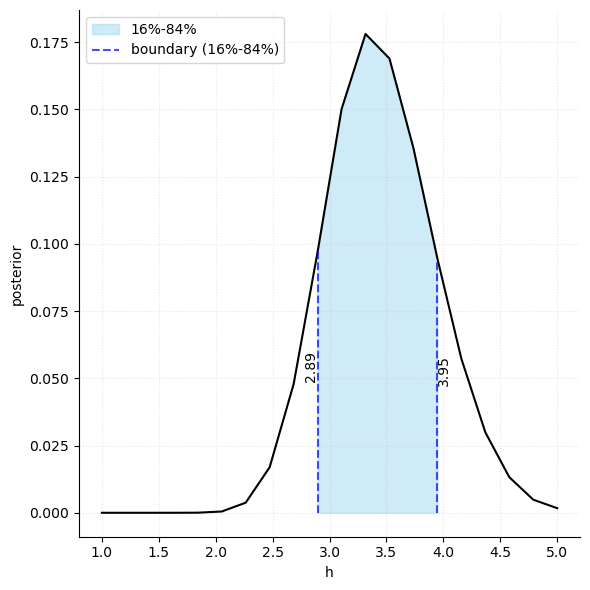

In [ ]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 假设你已有 x_array=HOf_array, marginal_prob 等变量
# 使用高斯滤波使分布更平滑
smoothed_prob = gaussian_filter1d(marginal_prob, sigma=1)  # sigma参数控制平滑程度

# 重新计算CDF和分位数
smoothed_prob = smoothed_prob / np.sum(smoothed_prob)  # 确保概率和为1
cdf = np.cumsum(smoothed_prob)
lower_percentile = 0.16  # 16%
upper_percentile = 0.84  # 84%
lower_idx = np.searchsorted(cdf, lower_percentile)
upper_idx = np.searchsorted(cdf, upper_percentile)
lower_bound = x_array[lower_idx]
upper_bound = x_array[upper_idx]

# 创建图像
fig, ax = plt.subplots(figsize=(6, 6))

# 绘制平滑后的概率密度函数
ax.plot(x_array, smoothed_prob, 'k-', linewidth=1.5)

# 填充上下界之间的区域
ax.fill_between(
    x_array[lower_idx:upper_idx+1],
    smoothed_prob[lower_idx:upper_idx+1],
    alpha=0.4,
    color='skyblue',
    label=f'16%-84%'
)

# 找出概率密度函数的顶部和底部边界
# 为了只在分布函数内绘制虚线
y_max = smoothed_prob[lower_idx:upper_idx+1].max()
y_min = 0  # 通常PDF在x轴上没有负值

# 添加只在分布函数内的上下界垂直线
ax.plot(
    [lower_bound, lower_bound],
    [y_min, smoothed_prob[lower_idx]],
    linestyle='--', color='blue', alpha=0.7
)
ax.plot(
    [upper_bound, upper_bound],
    [y_min, smoothed_prob[upper_idx]],
    linestyle='--', color='blue', alpha=0.7
)

# 添加垂直线的标签（不在线上，而是作为图例的一部分）
ax.plot([], [], linestyle='--', color='blue', alpha=0.7, 
        label=f'boundary (16%-84%)')

# 添加文本标注
ax.text(lower_bound, smoothed_prob[lower_idx]*0.5, 
        f'{lower_bound:.2f}', ha='right', va='bottom', rotation=90)
ax.text(upper_bound, smoothed_prob[upper_idx]*0.5, 
        f'{upper_bound:.2f}', ha='left', va='bottom', rotation=90)

# 设置坐标轴标签
ax.set_xlabel("h")
ax.set_ylabel('posterior')

# 提高图形整体美观度
ax.grid(alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加图例
ax.legend()

plt.tight_layout()

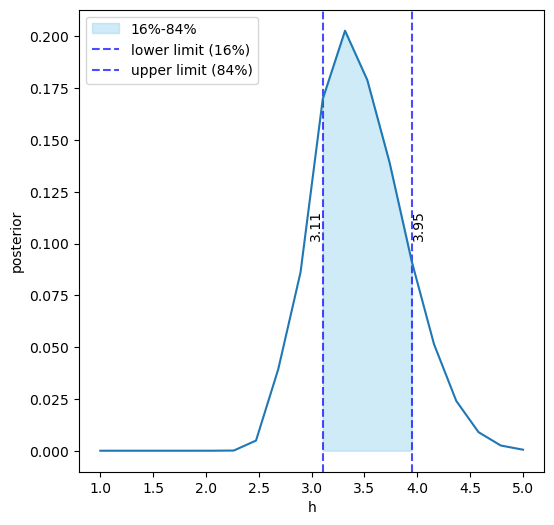

In [ ]:
x_array=HOf_array
marginal_prob = np.sum(posterior_4D, axis=(0,2,3))
marginal_prob = marginal_prob/np.sum(marginal_prob)

cdf = np.cumsum(marginal_prob)
lower_percentile = 0.16  # 16%
upper_percentile = 0.84  # 84%
lower_idx = np.searchsorted(cdf, lower_percentile)
upper_idx = np.searchsorted(cdf, upper_percentile)
lower_bound = x_array[lower_idx]
upper_bound = x_array[upper_idx]


fig, ax = plt.subplots(figsize=(6,6))
 
ax.fill_between(
    x_array[lower_idx:upper_idx+1],  # x值范围，从下界到上界
    marginal_prob[lower_idx:upper_idx+1],  # 对应的y值
    alpha=0.4,  # 透明度
    color='skyblue',  # 填充颜色
    label=f'16%-84%'  # 图例标签
)

# 添加上下界的垂直线
ax.axvline(x=lower_bound, linestyle='--', color='blue', alpha=0.7, label=f'lower limit ({lower_percentile:.0%})')
ax.axvline(x=upper_bound, linestyle='--', color='blue', alpha=0.7, label=f'upper limit ({upper_percentile:.0%})')

# 添加文本标注
ax.text(lower_bound, max(marginal_prob)*0.5, f'{lower_bound:.2f}', ha='right', va='bottom', rotation=90)
ax.text(upper_bound, max(marginal_prob)*0.5, f'{upper_bound:.2f}', ha='left', va='bottom', rotation=90)

ax.plot(x_array,marginal_prob)
ax.set_xlabel("h")
ax.set_ylabel('posterior')
# 添加图例
ax.legend()

/tmp/ipykernel_64073/2290726161.py:23: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


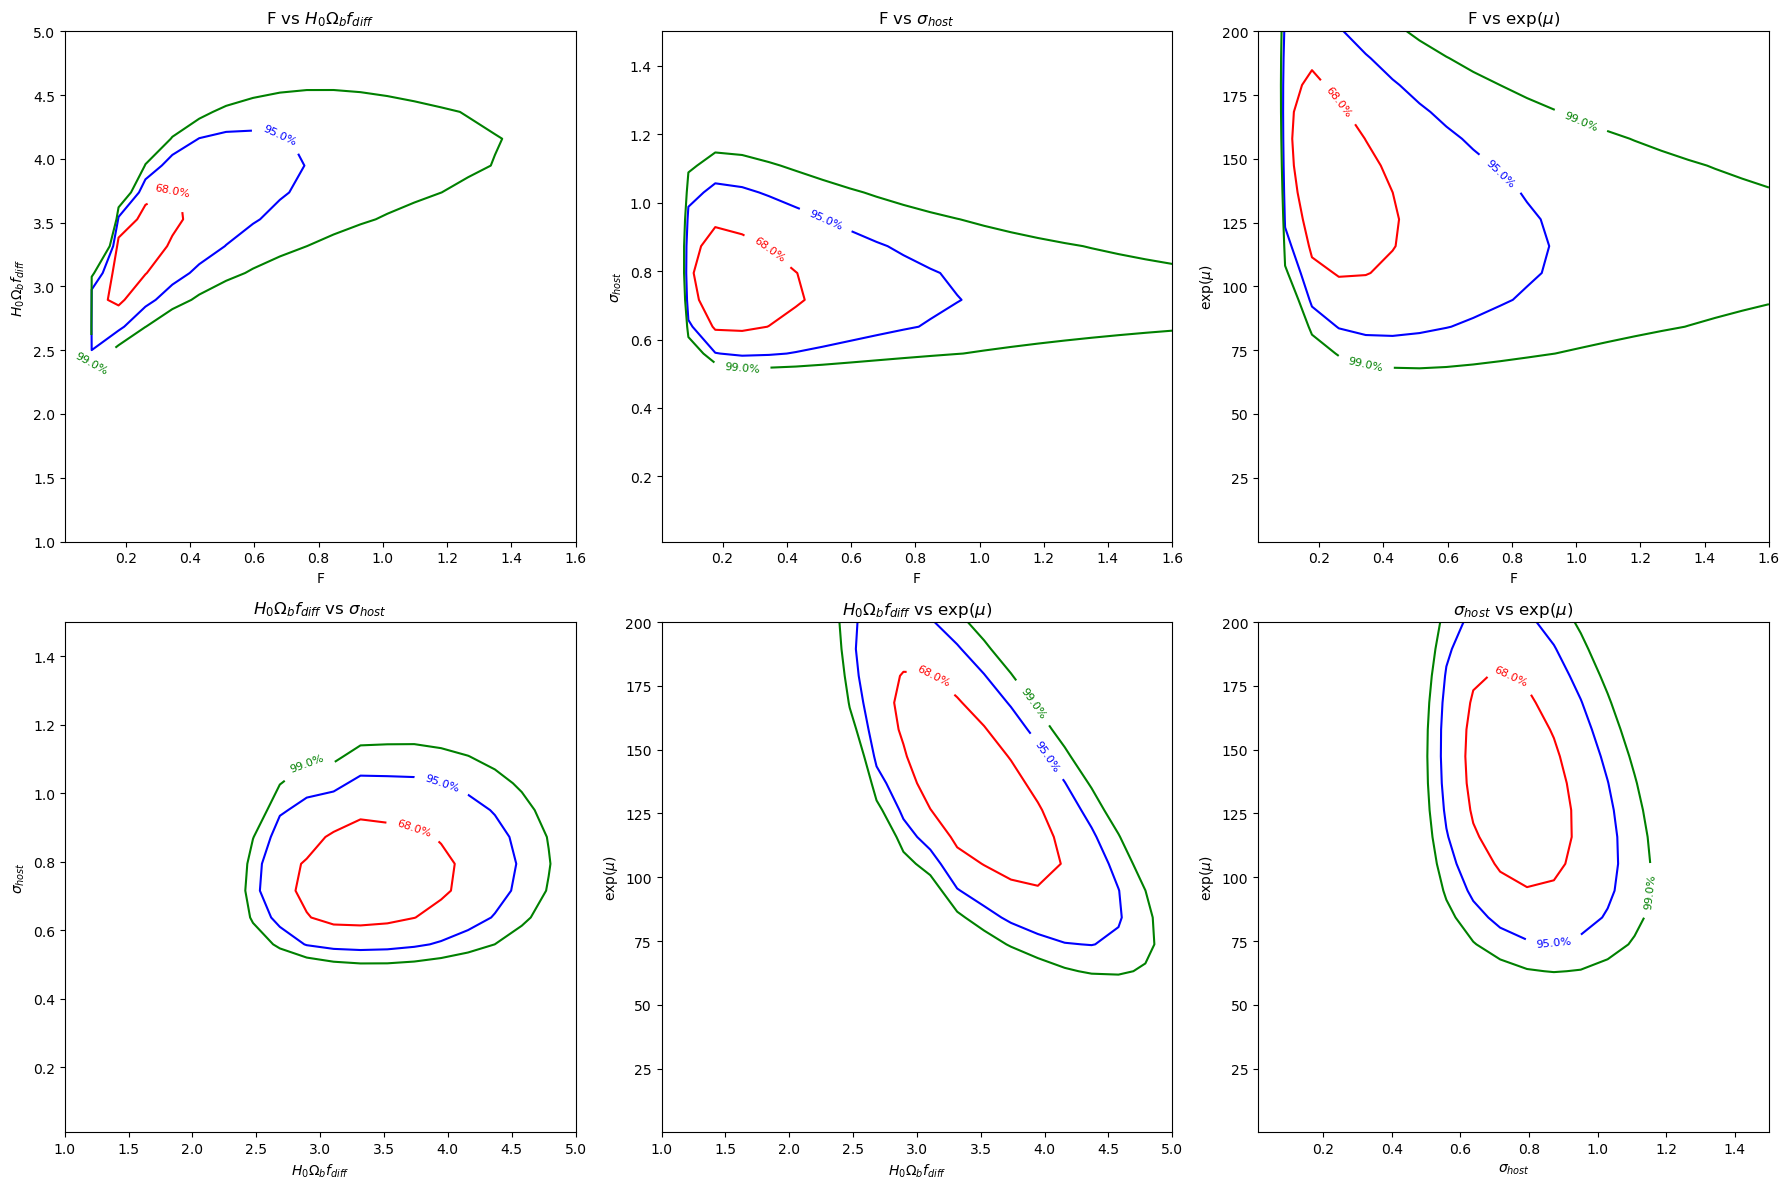

In [ ]:
# from scipy.stats import chi2

# # confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
# confidence_levels = [0.68, 0.95, 0.99]
# contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

# grid_pairs = [
#     ("F", "$H_0 \Omega_b f_{diff}$", (2, 3), F_h, h_F),
#     ("F", "$\sigma_{host}$", (1, 3), F_sigma, sigma_F),
#     ("F", "$\exp(\mu)$", (1, 2), F_e_mu, e_mu_F),
#     ("$H_0 \Omega_b f_{diff}$", "$\sigma_{host}$", (0, 3), h_sigma, sigma_h),
#     ("$H_0 \Omega_b f_{diff}$", "$\exp(\mu)$", (0, 2), h_e_mu, e_mu_h),
#     ("$\sigma_{host}$", "$\exp(\mu)$", (0, 1), sigma_e_mu, e_mu_sigma)
# ]

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# axes = axes.flatten()

# for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
#     marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
#     marginal_prob = marginal_prob/np.sum(marginal_prob)
    
#     delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
#     ax = axes[idx]
#     cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, 
#                     colors=['r', 'b', 'g']
#                     #colors=['r', 'b', 'g', 'orange', 'magenta', 'grey']
#                     )
    
#     ax.set_xlabel(x_var)
#     ax.set_ylabel(y_var)
#     ax.set_title(f"{x_var} vs {y_var}")
    
#     fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
#            contour_levels[1]: f'{confidence_levels[1]*100}%',
#            contour_levels[2]: f'{confidence_levels[2]*100}%',
#            #contour_levels[3]: f'{confidence_levels[3]*100}%',
#            #contour_levels[4]: f'{confidence_levels[4]*100}%',
#            #contour_levels[5]: f'{confidence_levels[5]*100}%'
#            }
#     ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

# plt.tight_layout()
# plt.show()

In [ ]:
# posterior_4D = np.load("./posterior/posterior_4D_MacF_no_2FRBs.npy")